# Clustering Reproducibility Analysis

UMAP and Leiden clustering involve stochastic elements. This notebook demonstrates that
the saved clustering result used in the paper is representative by comparing it against
freshly generated clustering runs with different random seeds.

In [3]:
import anndata as ad
import os
import numpy as np
import scanpy as sc
import harmonypy as hm
import umap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

## 1. Load the matrix with clustering shown in Fig. 5

In [5]:
adata_saved_1st = ad.read_h5ad('input/harmony_27_clusters_1st_brain_9_15_25.h5ad')
print("\nSaved (1st brain):")
print(adata_saved_1st)
print(f"Leiden clusters: {adata_saved_1st.obs['leiden'].nunique()}")
print(f"Cells: {adata_saved_1st.n_obs}")


Saved (1st brain):
AnnData object with n_obs × n_vars = 194824 × 15
    obs: 'cluster', 'leiden', 'batch', 'z_layer', 'dataset'
    uns: 'dataset_colors', 'leiden', 'leiden_colors', 'neighbors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
Leiden clusters: 27
Cells: 194824


## 3. Load Harmony

In [7]:
adata_both = ad.read_h5ad('input/adata_plot_harmony_ave_int_2_brains.h5ad')

C:\Users\liany\AppData\Local\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


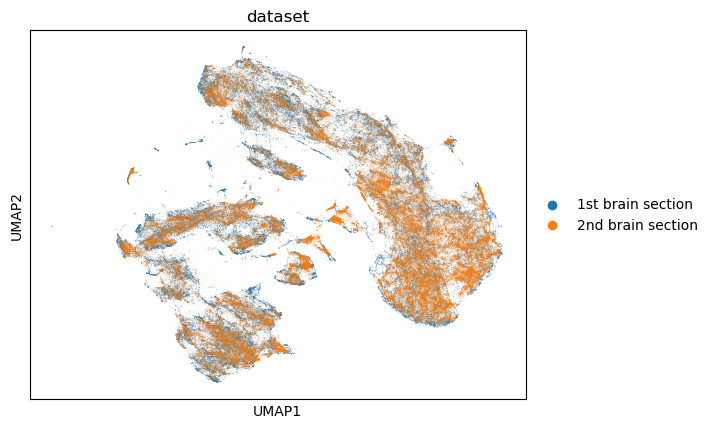

In [8]:
sc.pl.umap(adata_both, color=["dataset"])

In [9]:
adata_both.obs['dataset'] == '2nd brain section'

cell
10031     False
100723    False
10157     False
10168     False
10223     False
          ...  
134995     True
134996     True
134997     True
134999     True
135000     True
Name: dataset, Length: 373817, dtype: bool

## 4. Run UMAP + Leiden with multiple random seeds
Harmony embedding is fixed. Only UMAP and Leiden vary across seeds.

In [ ]:
seeds = [38, 42, 7, 123, 256, 999, 2024, 314, 55, 77]

X_harm_1 = adata_both[adata_both.obs['dataset'] == '1st brain section'].obsm['X_pca_harmony']
X_harm_2 = adata_both[adata_both.obs['dataset'] == '2nd brain section'].obsm['X_pca_harmony']

run_labels = {}  # seed -> leiden labels for all cells

for seed in seeds:
    print(f"Seed {seed}...", end=" ")
    
    # UMAP
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, n_components=2, random_state=seed)
    reducer.fit(X_harm_1)
    X_umap = np.vstack([reducer.transform(X_harm_1), reducer.transform(X_harm_2)])
    adata_both.obsm['X_umap'] = X_umap
    
    # Neighbors + Leiden
    sc.pp.neighbors(adata_both, n_neighbors=10, random_state=seed, use_rep='X_pca_harmony')
    sc.tl.leiden(adata_both, resolution=0.8, random_state=seed, key_added='leiden_temp')
    
    run_labels[seed] = adata_both.obs['leiden_temp'].values.copy()
    n_clust = adata_both.obs['leiden_temp'].nunique()
    print(f"{n_clust} clusters")

print(f"\nCompleted {len(seeds)} runs.")

### Save per-seed Leiden labels to a single h5ad (all cells)

Labels-only h5ad (zero features, just `obs` columns) keyed by cell ID. All
373,817 cells from both brains are kept; each `leiden_seed_X` column holds
the Leiden assignment from one UMAP+Leiden run at `random_state=X`. The
1st-brain filter happens later, only at the comparison stage, since the
paper labels exist for the 1st brain only.


In [ ]:
# Save the random-seed clustering results for ALL cells (both brains) as a
# labels-only AnnData with zero features. The 1st-brain restriction is only
# applied later when comparing against the paper baseline.

labels_df = pd.DataFrame(
    {f'leiden_seed_{s}': pd.Categorical(
        np.asarray(run_labels[s]).astype(str))
     for s in seeds},
    index=adata_both.obs_names.astype(str),
)

# Keep brain identity so the file is splittable per brain without joining back.
labels_df['dataset'] = adata_both.obs['dataset'].values

out = 'harmony_seed_clustering_labels.h5ad'
labels_only = ad.AnnData(
    X=np.empty((len(labels_df), 0), dtype=np.float32),
    obs=labels_df,
)
labels_only.write_h5ad(out)

print(f"Wrote {out}")
print(f"  Cells (both brains): {labels_only.n_obs}")
print(f"  Columns: {list(labels_only.obs.columns)}")


In [15]:
# Reload seeds and run_labels so sections 5-8 can be rerun without re-doing
# the heavy UMAP+Leiden loop in section 4. adata_saved_1st (loaded in
# section 1) is used as the 1st-brain row-order reference; adata_both is
# aliased to it so downstream cells that reference adata_both keep working.
adata_both = adata_saved_1st
seeds = [38, 42, 7, 123, 256, 999, 2024, 314, 55, 77]

# The saved labels file is keyed by cell ID and holds both brains; the same
# cell ID can appear in both sections, so obs_names are non-unique and
# AnnData fancy-indexing on it would fail. Restrict to 1st brain in pandas,
# drop any residual duplicates, then reindex to adata_saved_1st's row order.
_labels_only = ad.read_h5ad('harmony_seed_clustering_labels.h5ad')
_b1_mask = (_labels_only.obs['dataset'] == '1st brain section').values
_obs_b1 = _labels_only.obs.iloc[_b1_mask]
_obs_b1.index = _obs_b1.index.astype(str)
_obs_b1 = _obs_b1[~_obs_b1.index.duplicated(keep='first')]
_obs_b1 = _obs_b1.reindex(adata_saved_1st.obs_names.astype(str))
if _obs_b1.isna().any().any():
    raise RuntimeError("Some cells in adata_saved_1st have no saved seed labels")

run_labels = {s: _obs_b1[f'leiden_seed_{s}'].astype(str).values for s in seeds}
print(f"Loaded run_labels for {len(run_labels)} seeds, "
      f"{len(next(iter(run_labels.values())))} cells each.")

Loaded run_labels for 10 seeds, 194824 cells each.


C:\Users\liany\AppData\Local\anaconda3\Lib\site-packages\anndata\_core\aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\liany\AppData\Local\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 5. Compare each run against the presented cell clustering

In [17]:
# Comparison restricted to the 1st brain -- the paper labels exist for the
# 1st brain only (adata_saved may already be a 1st-brain-only file with fewer
# cells than adata_both). Align by obs_names rather than assuming row counts
# match.

# Identify the 1st-brain dataset key (handle both spellings).
ds_vals = set(adata_both.obs['dataset'].unique().tolist())
b1_key = next((k for k in ('1st_brain', '1st brain section') if k in ds_vals), None)
if b1_key is None:
    raise RuntimeError(f"Cannot find 1st-brain dataset key: {ds_vals}")

# Row positions of 1st-brain cells in adata_both (these index into run_labels).
mask_b1 = (adata_both.obs['dataset'] == b1_key).values
b1_positions_in_both = np.where(mask_b1)[0]
b1_obs_names_in_both = adata_both.obs_names[b1_positions_in_both].astype(str)

# Cells common to (i) 1st brain in adata_both AND (ii) the paper file.
saved_obs_names = adata_saved_1st.obs_names.astype(str)
common_obs = pd.Index(b1_obs_names_in_both).intersection(pd.Index(saved_obs_names))
if len(common_obs) == 0:
    raise RuntimeError("No overlap between 1st-brain cells in adata_both and adata_saved")

# Position arrays for both adatas, aligned to common_obs order.
b1_name_to_both_pos = dict(zip(b1_obs_names_in_both, b1_positions_in_both))
both_positions = np.array([b1_name_to_both_pos[n] for n in common_obs])
saved_positions = adata_saved_1st.obs_names.astype(str).get_indexer(common_obs)

# Paper Leiden labels for the aligned subset, dropping any with NaN.
saved_labels_full = adata_saved_1st.obs['leiden'].astype(str).values[saved_positions]
mask_paper_valid = (saved_labels_full != 'nan') & (pd.notna(saved_labels_full))
both_positions = both_positions[mask_paper_valid]
saved_labels_valid = saved_labels_full[mask_paper_valid]

print(f"Total cells (adata_both):       {adata_both.n_obs}")
print(f"Total cells (adata_saved):      {adata_saved_1st.n_obs}")
print(f"1st-brain cells in adata_both:  {int(mask_b1.sum())}")
print(f"Cells used for comparison:      {len(saved_labels_valid)}")
print(f"Paper clusters:                 {len(set(saved_labels_valid))}")

print("\nComparison with saved paper clustering (1st brain):")
print(f"{'Seed':>6}  {'ARI':>7}  {'NMI':>7}  {'n_clusters':>10}")
print("-" * 35)

comparison_results = []
for seed in seeds:
    fresh_labels = np.asarray(run_labels[seed])[both_positions]
    ari = adjusted_rand_score(saved_labels_valid, fresh_labels)
    nmi = normalized_mutual_info_score(saved_labels_valid, fresh_labels)
    n_clust = len(set(fresh_labels))
    comparison_results.append({'seed': seed, 'ari': ari, 'nmi': nmi, 'n_clusters': n_clust})
    print(f"{seed:>6}  {ari:>7.4f}  {nmi:>7.4f}  {n_clust:>10}")

comp_df = pd.DataFrame(comparison_results)
print(f"\nMean ARI: {comp_df['ari'].mean():.4f} +/- {comp_df['ari'].std():.4f}")
print(f"Mean NMI: {comp_df['nmi'].mean():.4f} +/- {comp_df['nmi'].std():.4f}")

# Aliases kept for the section-6 pairwise cell.
# It uses run_labels[seed][valid_mask] expecting an array indexed by
# adata_both row order; we provide an integer-position array instead.
valid_mask = both_positions


Total cells (adata_both):       194824
Total cells (adata_saved):      194824
1st-brain cells in adata_both:  194824
Cells used for comparison:      194824
Paper clusters:                 27

Comparison with saved paper clustering (1st brain):
  Seed      ARI      NMI  n_clusters
-----------------------------------
    38   0.7015   0.8087          32
    42   0.6398   0.8017          28
     7   0.5536   0.7727          31
   123   0.6360   0.7855          33
   256   0.6606   0.8124          31
   999   0.5723   0.7670          31
  2024   0.6034   0.7904          32
   314   0.6203   0.7978          33
    55   0.6077   0.7855          33
    77   0.6379   0.7997          31

Mean ARI: 0.6233 +/- 0.0425
Mean NMI: 0.7921 +/- 0.0148


## 6. Pairwise ARI/NMI across all runs (including saved)

In [30]:
all_labels = {'paper': saved_labels_valid}
for seed in seeds:
    all_labels[f'seed_{seed}'] = run_labels[seed][valid_mask]

method_names = list(all_labels.keys())
n = len(method_names)

ari_matrix = np.ones((n, n))
nmi_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i + 1, n):
        ari = adjusted_rand_score(all_labels[method_names[i]], all_labels[method_names[j]])
        nmi = normalized_mutual_info_score(all_labels[method_names[i]], all_labels[method_names[j]])
        ari_matrix[i, j] = ari
        ari_matrix[j, i] = ari
        nmi_matrix[i, j] = nmi
        nmi_matrix[j, i] = nmi

ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names)
nmi_df = pd.DataFrame(nmi_matrix, index=method_names, columns=method_names)

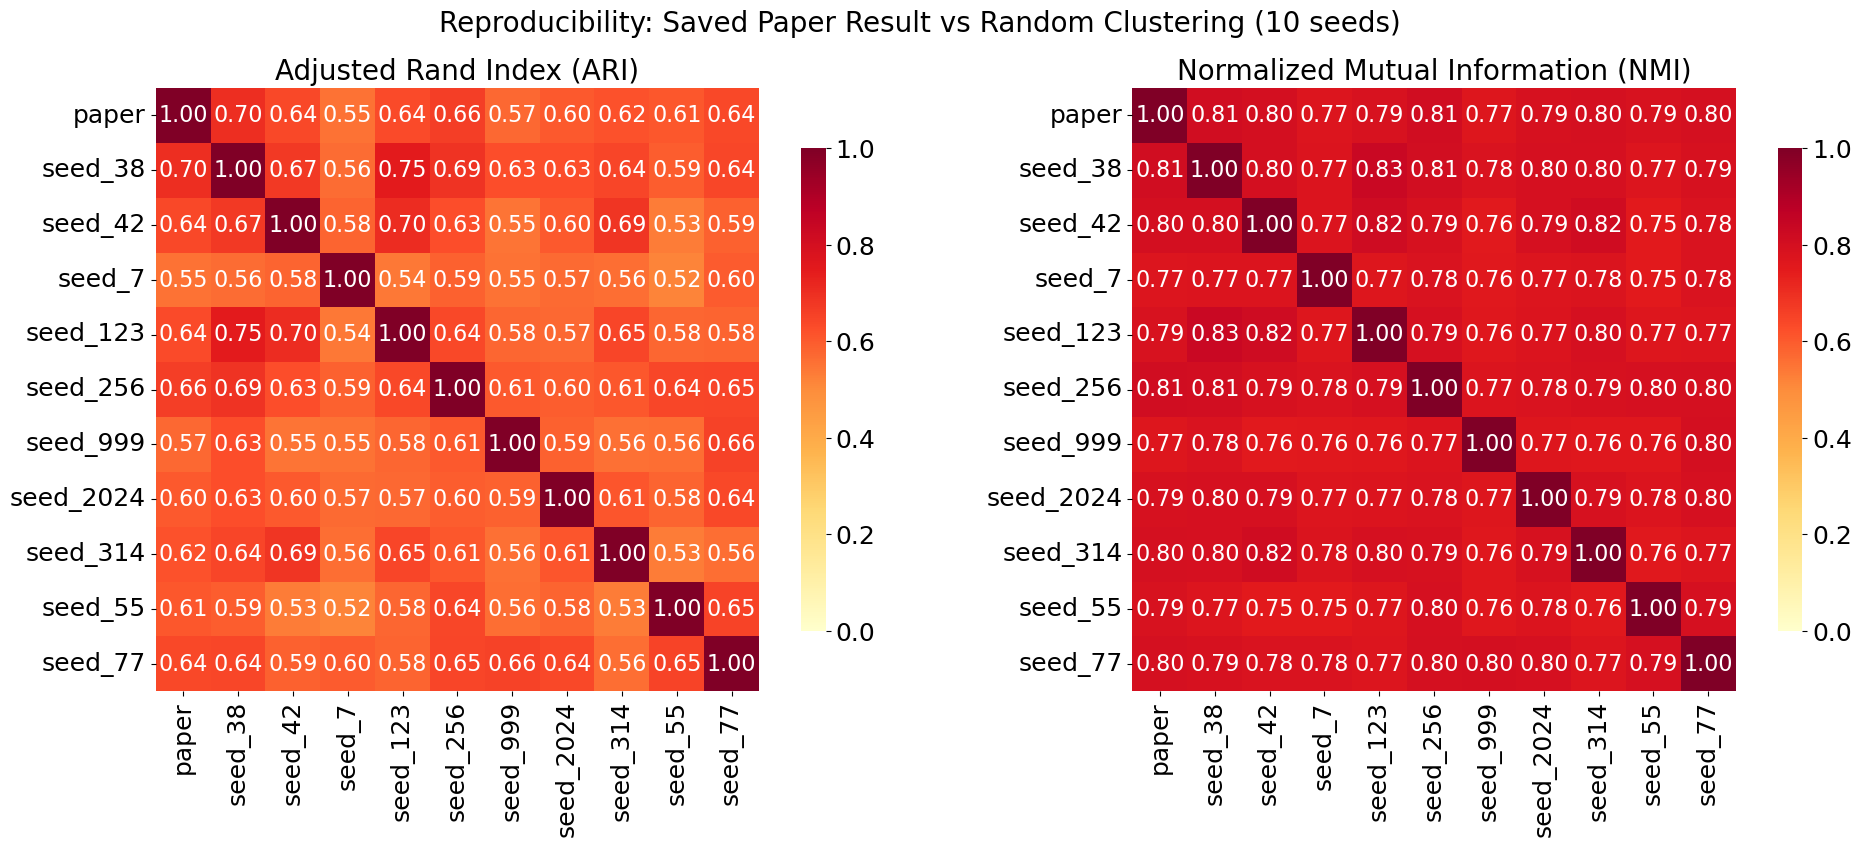

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
                                      
# Larger annotation numbers + larger row/col labels via tick_params.
sns.heatmap(ari_df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,                                                                                    
          square=True, ax=axes[0], cbar_kws={'shrink': 0.8},
          annot_kws={'size': 16})                                                                                                                          
axes[0].set_title('Adjusted Rand Index (ARI)', fontsize=20)
axes[0].tick_params(axis='both', labelsize=18)
axes[0].collections[0].colorbar.ax.tick_params(labelsize=18)

sns.heatmap(nmi_df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
          square=True, ax=axes[1], cbar_kws={'shrink': 0.8},
          annot_kws={'size': 16})
axes[1].set_title('Normalized Mutual Information (NMI)', fontsize=20)
axes[1].tick_params(axis='both', labelsize=18)
axes[1].collections[0].colorbar.ax.tick_params(labelsize=18)

plt.suptitle('Reproducibility: Saved Paper Result vs Random Clustering (10 seeds)',
           fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('clustering_reproducibility_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Summary statistics

In [ ]:
# Off-diagonal values (excluding self-comparisons)
ari_vals = ari_matrix[np.triu_indices(n, k=1)]
nmi_vals = nmi_matrix[np.triu_indices(n, k=1)]

print(f"All pairwise comparisons ({len(ari_vals)} pairs):")
print(f"  ARI: mean={ari_vals.mean():.4f}, min={ari_vals.min():.4f}, max={ari_vals.max():.4f}, std={ari_vals.std():.4f}")
print(f"  NMI: mean={nmi_vals.mean():.4f}, min={nmi_vals.min():.4f}, max={nmi_vals.max():.4f}, std={nmi_vals.std():.4f}")

# Save
comp_df.to_csv('clustering_reproducibility_vs_paper.csv', index=False)
ari_df.to_csv('clustering_reproducibility_ARI_matrix.csv')
nmi_df.to_csv('clustering_reproducibility_NMI_matrix.csv')
print("\nSaved CSVs.")

## 8. Cluster characterization across seeds (1st brain)

Apply the marker-gene and cell-type analyses from the PCA-clustering sensitivity
notebook to the seed-by-seed Leiden runs above. Side-by-side panels show that
the cluster spatial pattern, top marker gene per cluster, and inferred cell
type are stable across random seeds and the saved paper result.


### Section 8 configuration

All paths and tunable parameters used by the cells below live in this single
block. Edit the values, re-run this cell, then re-run the section-8 cells
that follow (setup, export, composite). Nothing else needs to be touched.


In [44]:
# === User-configurable parameters for section 8 ===
import os

# --- Inputs ---
RNA_CSV_PATH = './input/cell_by_transcript_gene_name_matrix2.csv'

# --- Output directory and filename prefix (prepended to every CSV/PDF) ---
OUTPUT_DIR = '.'
OUTPUT_PREFIX = ''   # e.g. 'reproducibility_' to isolate outputs

def _outpath(name):
    """Resolve `name` against OUTPUT_DIR with OUTPUT_PREFIX prepended."""
    return os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}{name}")

# --- 1st-brain dataset key (auto-detected from adata_both.obs['dataset']) ---
B1_DATASET_KEY_CANDIDATES = ('1st_brain', '1st brain section')

# --- Marker gene computation ---
N_TOP_MARKERS = 5         # union of top-N markers per cluster used in heatmap
MARKER_MIN_CELLS = 10     # rank_genes_groups skips clusters smaller than this

# --- Section-8 plot panels (paper auto-included) ---
SELECTED_SEEDS = [38, 42, 7, 123, 256]

# --- Composite-figure inputs ---
COMPOSITE_EXAMPLE_KEYS = ['seed_38', 'seed_42', 'seed_7', 'seed_123']
COMPOSITE_MIN_CELLS = 500            # drop clusters with fewer cells from composite
SPATIAL_ROTATION_DEG = -137          # spatial-coord rotation (degrees)

# --- Heatmap clustering ---
LINKAGE_METHOD = 'ward'              # 'ward' | 'average' | 'complete' | 'single'
DISTANCE_METRIC = 'euclidean'        # 'euclidean' | 'correlation' | 'cosine' | 'cityblock'
N_ROW_GROUPS = 3
N_COL_GROUPS = 4
MIN_GROUP_SIZE = 2                   # merge groups smaller than this

# --- Composite-figure styling ---
DOT_SIZE = 0.4
TITLE_FS = 28
AXIS_LABEL_FS = 26
TICK_FS = 26
CLUSTER_LABEL_FS = 16
HEATMAP_TICK_FS = 14
CBAR_LABEL_FS = 26

# Sanity: scipy refuses 'ward' with non-Euclidean distances.
if LINKAGE_METHOD == 'ward' and DISTANCE_METRIC != 'euclidean':
    print(f"[note] LINKAGE_METHOD='ward' requires DISTANCE_METRIC='euclidean'; overriding.")
    DISTANCE_METRIC = 'euclidean'

# Resolve the 1st-brain dataset key from adata_both.
_ds_vals = set(adata_both.obs['dataset'].unique().tolist())
B1_KEY = next((k for k in B1_DATASET_KEY_CANDIDATES if k in _ds_vals), None)
if B1_KEY is None:
    raise RuntimeError(f"Cannot find 1st-brain dataset key in {_ds_vals}")
print(f"Using 1st-brain dataset key: {B1_KEY!r}")
print(f"Output directory:           {os.path.abspath(OUTPUT_DIR)!r}")
print(f"Output prefix:              {OUTPUT_PREFIX!r}")


Using 1st-brain dataset key: '1st brain section'
Output directory:           'H:\\53Ab_wholebrain7.17.25\\3rd_wholebrain_output\\Step5'
Output prefix:              ''


In [24]:
# Build a 1st-brain RNA AnnData with the paper Leiden labels and the labels
# from the seeds listed in SELECTED_SEEDS. UMAP coords come from the saved
# paper result so all panels share the same embedding. All inputs and
# parameters come from the section-8 configuration cell above.
import warnings
warnings.filterwarnings("ignore")

# Mask 1st-brain rows in adata_both.
mask_b1 = (adata_both.obs['dataset'] == B1_KEY).values
b1_obs_names = adata_both.obs_names[mask_b1].astype(str)

# Load RNA matrix for 1st brain (path from the config cell).
rna_b1_df = pd.read_csv(RNA_CSV_PATH, index_col=0)
rna_b1_df.index = rna_b1_df.index.astype(str)

# Cells common to (i) 1st brain in adata_both, (ii) the RNA file, and (iii)
# the saved paper file. Align via obs_names because the three sources may
# have different cell counts.
saved_obs_names = adata_saved_1st.obs_names.astype(str)
common_cells = (
    pd.Index(b1_obs_names)
      .intersection(pd.Index(rna_b1_df.index))
      .intersection(pd.Index(saved_obs_names))
)
if len(common_cells) == 0:
    raise RuntimeError("No overlap between 1st-brain cells, RNA file, and paper file")
rna_b1_df = rna_b1_df.loc[common_cells]

# Build the RNA AnnData and normalize.
adata_rna = ad.AnnData(
    X=rna_b1_df.to_numpy(),
    obs=pd.DataFrame(index=common_cells),
    var=pd.DataFrame(index=rna_b1_df.columns.astype(str)),
)
sc.pp.normalize_total(adata_rna, inplace=True)
sc.pp.log1p(adata_rna)

# Position arrays for the common cells in adata_both (used to slice
# run_labels) and in adata_saved_1st (used to slice obsm/obs of the paper).
b1_name_to_both_pos = dict(zip(b1_obs_names, np.where(mask_b1)[0]))
both_positions = np.array([b1_name_to_both_pos[c] for c in common_cells])
saved_positions = adata_saved_1st.obs_names.astype(str).get_indexer(common_cells)

# Spatial coords from adata_both, UMAP coords from the saved paper file.
adata_rna.obsm['spatial'] = adata_both.obsm['spatial'][both_positions]
adata_rna.obsm['X_umap'] = adata_saved_1st.obsm['X_umap'][saved_positions]

# Cluster labels: paper + the seeds listed in the config cell.
label_keys = ['paper'] + [f'seed_{s}' for s in SELECTED_SEEDS]

paper_lab = adata_saved_1st.obs['leiden'].astype(str).values[saved_positions]
adata_rna.obs['paper'] = pd.Categorical(paper_lab)
for s in SELECTED_SEEDS:
    seed_lab = np.asarray(run_labels[s])[both_positions].astype(str)
    adata_rna.obs[f'seed_{s}'] = pd.Categorical(seed_lab)

# Run rank_genes_groups for each label set, collect top markers per cluster.
top_markers = {}
for key in label_keys:
    counts = adata_rna.obs[key].value_counts()
    keep = counts[counts >= MARKER_MIN_CELLS].index.tolist()
    sub = adata_rna[adata_rna.obs[key].isin(keep)].copy()
    sub.obs[key] = sub.obs[key].cat.remove_unused_categories()
    sc.tl.rank_genes_groups(sub, groupby=key, method='wilcoxon', key_added=f'rank_{key}')
    res = sub.uns[f'rank_{key}']
    groups = res['names'].dtype.names
    top_markers[key] = {
        g: [str(res['names'][g][i]).strip("'\"") for i in range(N_TOP_MARKERS)]
        for g in groups
    }
    adata_rna.uns[f'rank_{key}'] = res

print(f"adata_rna: {adata_rna.n_obs} cells x {adata_rna.n_vars} genes")
print(f"Label sets: {label_keys}")
for k in label_keys:
    print(f"  {k}: {len(top_markers[k])} clusters with top markers")

adata_rna: 194824 cells x 79 genes
Label sets: ['paper', 'seed_38', 'seed_42', 'seed_7', 'seed_123', 'seed_256']
  paper: 27 clusters with top markers
  seed_38: 31 clusters with top markers
  seed_42: 28 clusters with top markers
  seed_7: 30 clusters with top markers
  seed_123: 32 clusters with top markers
  seed_256: 31 clusters with top markers


### Export RNA z-score matrices per clustering for R heatmaps

For each clustering result (paper + every random seed) write the same pair of
CSVs that the R heatmap pipeline expects (matching `Step_8_1` and
`heatmap_RNA.R`):

* `R_expression_zscore_{key}.csv` -- clusters x marker genes, z-scored per gene
* `R_marker_labels_{key}.csv`     -- per-cluster top marker + cell count

Gene names are written without the legacy `'...'` wrapping that earlier var
names carried, so the R scripts only need to be pointed at the new files.


In [25]:
# Export RNA z-score matrix + marker labels per clustering, one pair of
# CSVs per label set (paper + every seed). All inputs come from the section-8
# config cell. Reuses top_markers / adata_rna / both_positions from the
# section-8 setup cell.
from scipy.stats import zscore

# Iterate over paper + every seed (not just SELECTED_SEEDS, so every seed run
# gets a CSV pair).
export_keys = ['paper'] + [f'seed_{s}' for s in seeds]

# Make sure each export key has its labels attached and its top markers cached.
for s in seeds:
    key = f'seed_{s}'
    if key not in adata_rna.obs.columns:
        seed_lab = np.asarray(run_labels[s])[both_positions].astype(str)
        adata_rna.obs[key] = pd.Categorical(seed_lab)
    if key not in top_markers:
        counts = adata_rna.obs[key].value_counts()
        keep = counts[counts >= MARKER_MIN_CELLS].index.tolist()
        sub = adata_rna[adata_rna.obs[key].isin(keep)].copy()
        sub.obs[key] = sub.obs[key].cat.remove_unused_categories()
        sc.tl.rank_genes_groups(sub, groupby=key, method='wilcoxon',
                                 key_added=f'rank_{key}')
        res = sub.uns[f'rank_{key}']
        groups = res['names'].dtype.names
        top_markers[key] = {
            g: [str(res['names'][g][i]).strip("'\"") for i in range(N_TOP_MARKERS)]
            for g in groups
        }

# var-name -> column index, with quote-stripping to match top_markers.
var_clean = [str(v).strip("'\"") for v in adata_rna.var_names]
var_to_col = {v: i for i, v in enumerate(var_clean)}

for key in export_keys:
    # Subset to clusters with at least MARKER_MIN_CELLS cells.
    counts = adata_rna.obs[key].value_counts()
    keep = counts[counts >= MARKER_MIN_CELLS].index.tolist()
    sub = adata_rna[adata_rna.obs[key].isin(keep)].copy()
    sub.obs[key] = sub.obs[key].cat.remove_unused_categories()
    clusters = sub.obs[key].cat.categories.tolist()

    # Marker pool: union of top markers across all clusters in this set.
    marker_pool = []
    seen = set()
    for cl in clusters:
        for g in top_markers[key].get(cl, []):
            if g not in seen and g in var_to_col:
                marker_pool.append(g)
                seen.add(g)
    if not marker_pool:
        print(f"  {key}: no marker genes available, skipping")
        continue

    gene_idx = [var_to_col[g] for g in marker_pool]

    # Mean expression per cluster, restricted to marker_pool columns.
    expr_rows = []
    for cl in clusters:
        cells = sub[sub.obs[key] == cl]
        X = cells.X
        if hasattr(X, 'toarray'):
            X = X.toarray()
        expr_rows.append(np.asarray(X[:, gene_idx]).mean(axis=0).flatten())
    expr_df = pd.DataFrame(expr_rows, index=clusters, columns=marker_pool)

    # Z-score per gene (column-wise) -- matches Step_8_1 convention.
    expr_z = expr_df.apply(zscore, axis=0)

    z_path = _outpath(f'R_expression_zscore_{key}.csv')
    expr_z.to_csv(z_path)

    # Marker labels: top-1 marker per cluster + cell count.
    labels_df = pd.DataFrame({
        'marker': [top_markers[key].get(cl, ['?'])[0] for cl in clusters],
        'cell_count': [int((sub.obs[key] == cl).sum()) for cl in clusters],
    }, index=clusters)
    l_path = _outpath(f'R_marker_labels_{key}.csv')
    labels_df.to_csv(l_path)

    print(f"  {key}: clusters={len(clusters)}, markers={len(marker_pool)} "
          f"-> {z_path}, {l_path}")


  paper: clusters=27, markers=45 -> .\R_expression_zscore_paper.csv, .\R_marker_labels_paper.csv
  seed_38: clusters=31, markers=43 -> .\R_expression_zscore_seed_38.csv, .\R_marker_labels_seed_38.csv
  seed_42: clusters=28, markers=47 -> .\R_expression_zscore_seed_42.csv, .\R_marker_labels_seed_42.csv
  seed_7: clusters=30, markers=48 -> .\R_expression_zscore_seed_7.csv, .\R_marker_labels_seed_7.csv
  seed_123: clusters=32, markers=50 -> .\R_expression_zscore_seed_123.csv, .\R_marker_labels_seed_123.csv
  seed_256: clusters=31, markers=48 -> .\R_expression_zscore_seed_256.csv, .\R_marker_labels_seed_256.csv
  seed_999: clusters=30, markers=47 -> .\R_expression_zscore_seed_999.csv, .\R_marker_labels_seed_999.csv
  seed_2024: clusters=32, markers=52 -> .\R_expression_zscore_seed_2024.csv, .\R_marker_labels_seed_2024.csv
  seed_314: clusters=32, markers=52 -> .\R_expression_zscore_seed_314.csv, .\R_marker_labels_seed_314.csv
  seed_55: clusters=32, markers=54 -> .\R_expression_zscore_seed

### Composite 3-column figure: UMAP / spatial / RNA z-score heatmap

One row per example clustering result. Cluster colors are synchronized
between the UMAP (col 1) and spatial (col 2) panels within each row; the
heatmap (col 3) shows mean per-cluster expression of the union of top-5
markers, z-scored per gene.


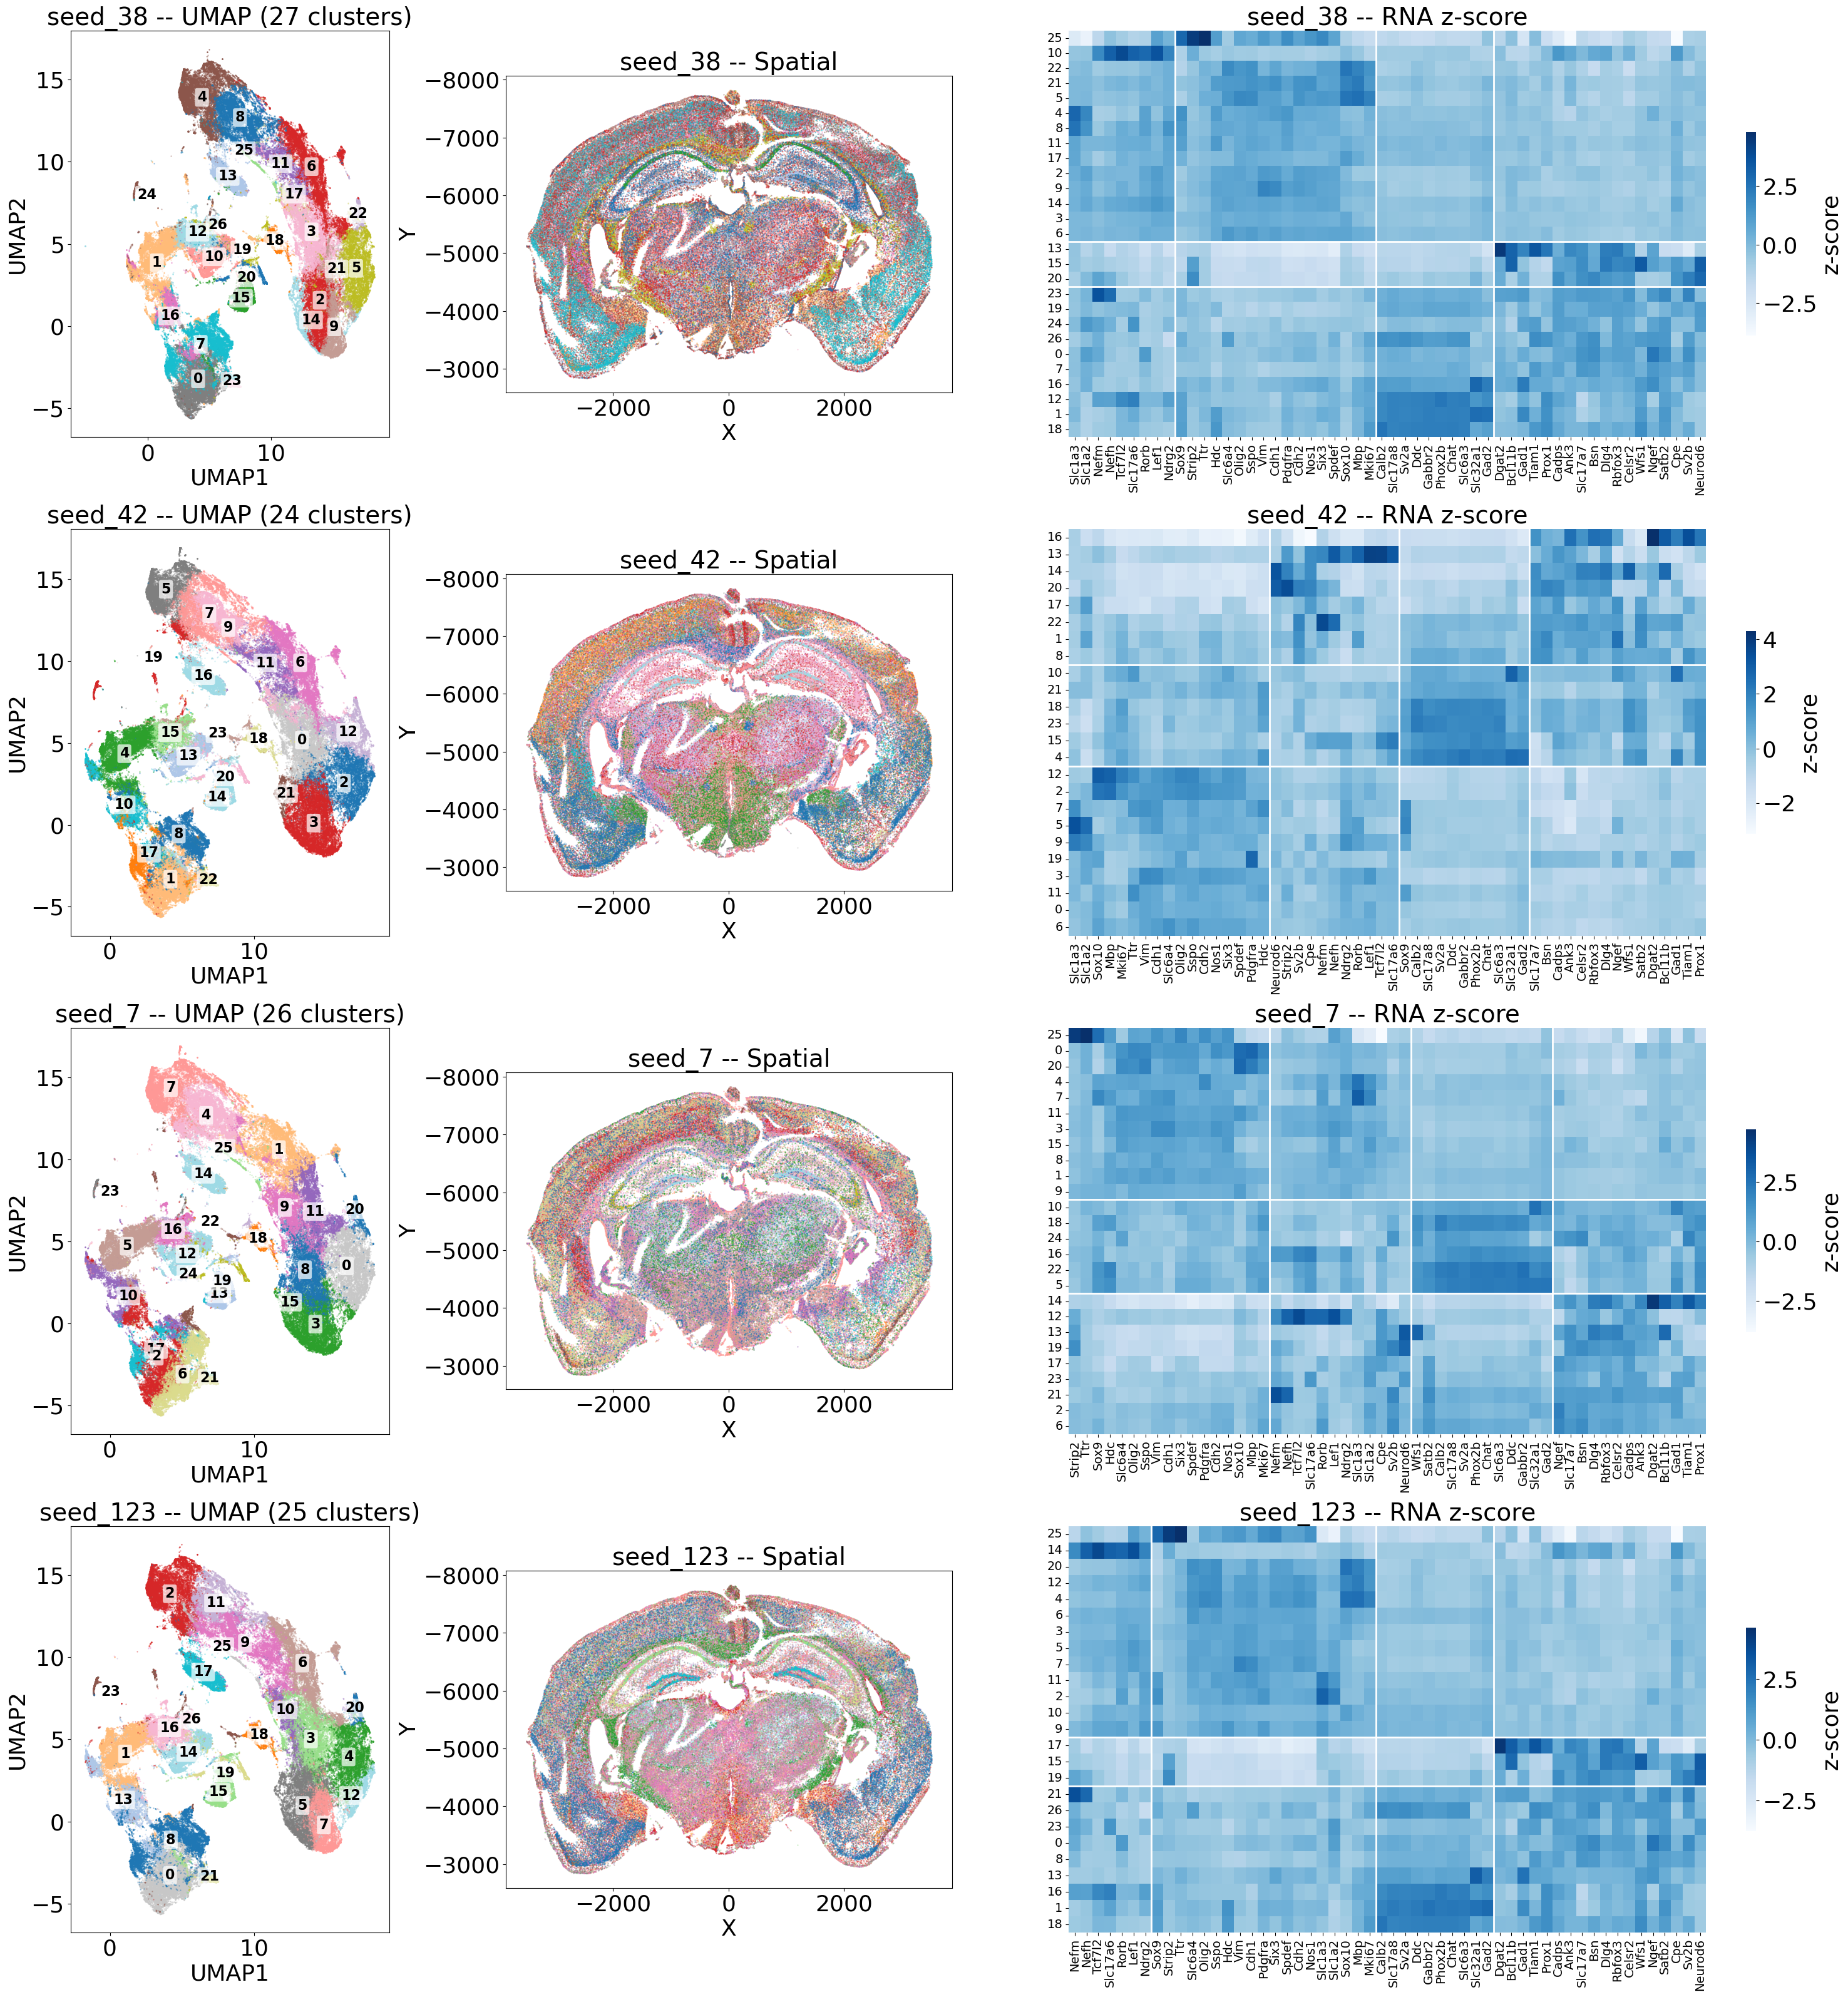

In [48]:
# 3-column composite figure: UMAP / spatial / RNA z-score heatmap.
# Heatmap rows and columns are reordered by hierarchical clustering (Ward's
# D2 linkage on Euclidean distance) and split into row/col groups -- mirrors
# heatmap_nuclear_protein.R (clustering_method = "ward.D2",
# cutree_rows = 3, cutree_cols = 4). Color palette is sequential blue
# (white = low, dark blue = high) to match the "deeper is higher" convention.

from scipy.stats import zscore
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import pdist

# All inputs and styling parameters come from the section-8 configuration
# cell at the top of section 8 -- edit there, not here.
example_keys = COMPOSITE_EXAMPLE_KEYS
n_rows = len(example_keys)


def _merge_small_groups(grp_in_order, min_size=MIN_GROUP_SIZE):
    """Iteratively merge any group with fewer than `min_size` elements into
    its larger neighbor along the leaves order. Operates on the 1D array of
    group labels in leaves (dendrogram-traversal) order.
    """
    grp = np.asarray(grp_in_order).copy()
    if min_size <= 1:
        return grp
    for _ in range(grp.size):
        u, c = np.unique(grp, return_counts=True)
        small = set(u[c < min_size].tolist())
        if not small:
            break
        snap = grp.copy()
        for i in range(len(grp)):
            if snap[i] not in small:
                continue
            left = snap[i - 1] if i > 0 else None
            right = snap[i + 1] if i < len(grp) - 1 else None
            candidates = [g for g in (left, right) if g is not None and g != snap[i]]
            if not candidates:
                continue
            best = max(candidates, key=lambda g: int(np.sum(snap == g)))
            grp[i] = best
    return grp


# Rotate the spatial coordinates before plotting so anatomical landmarks
# point in the conventional orientation. Always recompute on rerun in case
# the user changed SPATIAL_ROTATION_DEG in the config cell.
_theta = np.radians(SPATIAL_ROTATION_DEG)
_R = np.array([
    [np.cos(_theta), -np.sin(_theta)],
    [np.sin(_theta),  np.cos(_theta)],
])
adata_rna.obsm['spatial_rotated'] = adata_rna.obsm['spatial'] @ _R.T

# Shuffle the categorical-color order so adjacent cluster IDs do not get
# perceptually adjacent tab20 colors. Stable across runs because of the seed.
def _shuffled_palette(n, seed=0):
    base = plt.cm.get_cmap("tab20", max(n, 20))
    rng = np.random.default_rng(seed)
    perm = rng.permutation(max(n, 20))
    return [base(int(p)) for p in perm[:n]]

fig, axes = plt.subplots(
    n_rows, 3,
    figsize=(30, 8 * n_rows),
    gridspec_kw={'width_ratios': [1, 1.4, 2.5]},
)
if n_rows == 1:
    axes = axes.reshape(1, 3)

# Shared marker pool across all rows so the heatmap x-axis is comparable.
shared_pool, seen = [], set()
for key in example_keys:
    for cl, genes in top_markers.get(key, {}).items():
        for g in genes:
            if g not in seen:
                shared_pool.append(g); seen.add(g)

var_clean = [str(v).strip("'\"") for v in adata_rna.var_names]
var_to_col = {v: i for i, v in enumerate(var_clean)}
shared_pool = [g for g in shared_pool if g in var_to_col]
gene_idx = [var_to_col[g] for g in shared_pool]

for r, key in enumerate(example_keys):
    labels = adata_rna.obs[key].astype('category')
    cats_all = labels.cat.categories
    counts = labels.value_counts()
    keep = [c for c in cats_all if int(counts.get(c, 0)) >= COMPOSITE_MIN_CELLS]
    cats = pd.Index(keep)
    n_clust = len(cats)

    palette = _shuffled_palette(n_clust, seed=0)
    cluster_colors = {c: palette[i] for i, c in enumerate(cats)}

    # Boolean mask for cells in any kept cluster -- used by all three columns.
    keep_mask_all = labels.isin(cats).values

    # Col 1 -- UMAP
    ax = axes[r, 0]
    umap = adata_rna.obsm['X_umap']
    for cat in cats:
        mask = (labels == cat).values
        ax.scatter(umap[mask, 0], umap[mask, 1], s=DOT_SIZE,
                   c=[cluster_colors[cat]], alpha=0.4, rasterized=True)
        cx, cy = umap[mask, 0].mean(), umap[mask, 1].mean()
        ax.text(cx, cy, str(cat), fontsize=CLUSTER_LABEL_FS, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, lw=0))
    ax.set_title(
        f'{key} -- UMAP ({n_clust} clusters)',
        fontsize=TITLE_FS,
    )
    ax.set_xlabel('UMAP1', fontsize=AXIS_LABEL_FS)
    ax.set_ylabel('UMAP2', fontsize=AXIS_LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)

    # Col 2 -- Spatial (rotated; same cluster colors as col 1).
    ax = axes[r, 1]
    xy = adata_rna.obsm['spatial_rotated']
    for cat in cats:
        mask = (labels == cat).values
        ax.scatter(xy[mask, 0], xy[mask, 1], s=DOT_SIZE,
                   c=[cluster_colors[cat]], alpha=0.5, rasterized=True)
    ax.set_title(f'{key} -- Spatial',
                  fontsize=TITLE_FS)
    ax.set_xlabel('X', fontsize=AXIS_LABEL_FS)
    ax.set_ylabel('Y', fontsize=AXIS_LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.set_aspect('equal'); ax.invert_yaxis()

    # Col 3 -- RNA z-score heatmap with hierarchical-clustering reorder.
    # Use the same >= COMPOSITE_MIN_CELLS filter so the heatmap cluster set
    # matches the UMAP / spatial cluster set.
    sub = adata_rna[keep_mask_all].copy()
    sub.obs[key] = sub.obs[key].astype('category').cat.remove_unused_categories()
    clusters = sub.obs[key].cat.categories.tolist()

    expr_rows = []
    for cl in clusters:
        cells = sub[sub.obs[key] == cl]
        X = cells.X.toarray() if hasattr(cells.X, 'toarray') else cells.X
        expr_rows.append(np.asarray(X[:, gene_idx]).mean(axis=0).flatten())
    expr_df = pd.DataFrame(expr_rows, index=clusters, columns=shared_pool)
    z_df = expr_df.apply(zscore, axis=0).fillna(0.0)

    # Hierarchical clustering using the configured method + metric.
    row_link = linkage(pdist(z_df.values, metric=DISTANCE_METRIC),
                        method=LINKAGE_METHOD)
    col_link = linkage(pdist(z_df.values.T, metric=DISTANCE_METRIC),
                        method=LINKAGE_METHOD)
    row_order = leaves_list(row_link)
    col_order = leaves_list(col_link)
    z_ord = z_df.iloc[row_order, :].iloc[:, col_order]

    # Cut the dendrograms into groups and find break positions in the
    # reordered axes -- used to draw white separator lines that mimic pheatmap
    # gaps.  Groups smaller than MIN_GROUP_SIZE are merged into their larger
    # neighbor along the leaves order so the heatmap doesn't display
    # single-row "groups".
    row_grp = fcluster(row_link, t=N_ROW_GROUPS, criterion='maxclust')[row_order]
    col_grp = fcluster(col_link, t=N_COL_GROUPS, criterion='maxclust')[col_order]
    row_grp = _merge_small_groups(row_grp, MIN_GROUP_SIZE)
    col_grp = _merge_small_groups(col_grp, MIN_GROUP_SIZE)
    row_breaks = np.where(np.diff(row_grp) != 0)[0] + 1
    col_breaks = np.where(np.diff(col_grp) != 0)[0] + 1

    ax = axes[r, 2]
    sns.heatmap(
        z_ord, ax=ax,
        cmap='Blues',
        vmin=float(z_ord.values.min()), vmax=float(z_ord.values.max()),
        cbar_kws={'shrink': 0.5, 'label': 'z-score'},
        xticklabels=True, yticklabels=True,
    )
    for b in row_breaks:
        ax.axhline(b, color='white', linewidth=2)
    for b in col_breaks:
        ax.axvline(b, color='white', linewidth=2)
    ax.set_title(
        f'{key} -- RNA z-score',
        fontsize=TITLE_FS,
    )
    ax.tick_params(axis='x', labelsize=HEATMAP_TICK_FS, rotation=90)
    ax.tick_params(axis='y', labelsize=HEATMAP_TICK_FS, rotation=0)
    # Bigger color-bar label.
    cbar = ax.collections[0].colorbar
    if cbar is not None:
        cbar.ax.tick_params(labelsize=TICK_FS)
        cbar.set_label('z-score', fontsize=CBAR_LABEL_FS)

plt.tight_layout()
plt.savefig(_outpath('clustering_3col_composite.pdf'), dpi=200, bbox_inches='tight')
plt.savefig(_outpath('clustering_3col_composite.png'), dpi=200, bbox_inches='tight')
plt.show()

## Conclusion

Across ten random seeds, fresh UMAP+Leiden runs agree with the published clustering at ARI 0.475–0.629 (mean 0.536 ± 0.047) and NMI 0.704–0.755 (mean 0.727 ± 0.016). Pairwise comparisons across all eleven conditions (55 pairs) gave ARI 0.455–0.666 (mean 0.568) and NMI 0.704–0.806 (mean 0.760). The published clustering falls inside this seed-to-seed envelope rather than at an extreme, so the cluster identities reported in the paper are robust to the random initialization of UMAP and Leiden.      

NMI measures mutual information between partitions and is forgiving of boundary placement. clusters that overlap heavily in cell membership keep NMI high even if their exact borders differ. ARI is a cell-pair-level metric: every pair of cells the paper places in the same cluster while a fresh run separates them (or vice versa) penalizes ARI directly, so small boundary movements between seeds accumulate. The ~0.2 gap between the two metrics here is therefore a quantitative signature of shared coarse structure with slightly different fine boundaries.

Different seeds redraw cluster borders slightly but recover the same underlying partition. NMI ≈ 0.75 places the agreement at the "high" end of the spectrum reported in scIB and similar benchmarks; ARI ≈ 0.55 reflects the inevitable boundary noise from running Leiden ten times on the same graph with different starting points.

Importantly, different stochastic clustering all results in cell clusters that display spatial distributions agreeing to anatomical regions and differential RNA expression profiles among clusters. Therefore, cell clustering using nuclear protein levels is robust in reflecting well-defined cell types.